# Test the Turing module

In [1]:
# including packages
using LazyGrids, PyPlot, BenchmarkTools
using PSFModels, ImageFiltering, Statistics
# for Turing
using Turing,StatsPlots,PairPlots, CairoMakie

using Jens
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensModel as Jmodel
using Jens:LightModel as Jlight

using Jens.LensModel:NIEkappa as NIEkappa
using Jens.LightModel:GaussianLight as GaussianLight

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


## Simulating the Lensed Images

In [2]:
xg, yg = LU.LensGrid(;xl=2., nx=51)

# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.1,
                :xcentre=>0.03, :ycentre=>0.0)
# Gaussian Light Profile
SourceLight = GaussianLight.GaussianSphere(xg, yg;
             LightParaDict...);

LensParaDict = Dict(:b => 1., :s => 0.1,
 :q => 0.7, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);

Matrix{Float64}(51, 51)Float64()Matrix{Float64}(51, 51)Float64()

sys:1: UserWarning: The following kwargs were not used by contour: 'colorbar', 'size', 'xlabel', 'ylabel'


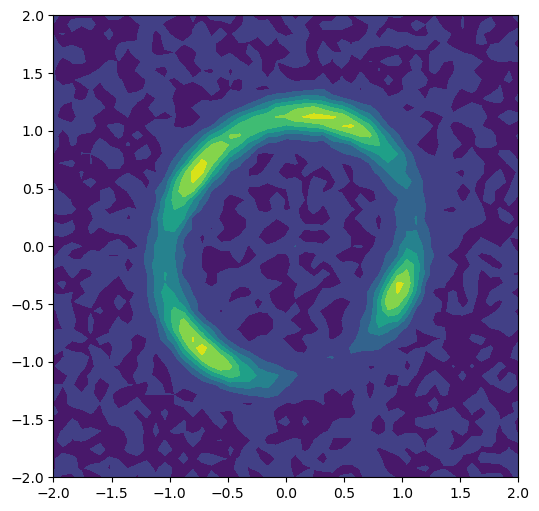

In [3]:
# Simulate the lensed image
data = LB.LensRayShooting(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict
                            ,SourceProfile=GaussianLight.GaussianSphere,SourceKwargs=LightParaDict);
σ_noise = 0.5
data = data .+ rand(Normal(0, σ_noise), size(data))

FigLnes = PyPlot.figure(figsize=(6, 6))
L2 = plt.contourf(xg, yg, data, size=(450,400), colorbar=true, xlabel="x (pix)", ylabel="y (pix)")
gcf()

In [5]:
plt.clf()

## Turing module

### set @model manually

For most generalized lensing parameter fittness, 
users are allowed to setting the lens parameters themselves, as  shown in the following model

In [6]:
@model function fit_lensed(x, y, data_obs)
    # Priors for parameters
    
    # set up the prior distributions for lens parameters
    # set NIEkappa's parameters via Normal distribution
    # truncated set the lower and upper bondary for distributions
    b ~ truncated(Normal(1., 1), 0, 5)
    s  ~ truncated(Normal(0., 1), 0, 0.1)
    q  ~ truncated(Normal(0.5, 1.0), 0.1, 1)
    varphi ~ truncated(Normal(-pi/6, 1), -pi, pi)
    xcentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    ycentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    
    ParaDict = Dict(:b => b, :s => s,
                :q => q, :varphi =>  varphi,
                :xcentre => xcentre, :ycentre => ycentre);
    
    # setup Lens light or Surce light if used

    # adapt a normal noise
    σ_noise ~ truncated(Normal(1, 1), 0, 5)

    # set up model
    model_intensity = LB.LensRayShooting(x, y; LensModel=NIEkappa, LensKwargs=ParaDict,
                        SourceProfile=GaussianLight.GaussianSphere, SourceKwargs=LightParaDict);

    # setup Likelihood
    for i in eachindex(data_obs)
        # only consider the value greater than background noise, s.t. noise = mean(data_obs)/5 here.
        if data_obs[i] > mean(data_obs)
            data_obs[i] ~ Normal(model_intensity[i], σ_noise)
        end
    end
end

fit_lensed (generic function with 2 methods)

In [8]:
chain = sample(fit_lensed(xg, yg, data),
         NUTS(400,0.65), 1000)#,  MCMCThreads(), 1000, 4)

Chains MCMC chain (1000×19×1 Array{Float64, 3}):

Iterations        = 401:1:1400
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 190.66 seconds
Compute duration  = 190.66 seconds
parameters        = b, s, q, varphi, xcentre, ycentre, σ_noise
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse    ess_bulk   ess_tail      rhat    ⋯
      Symbol   Float64   Float64   Float64     Float64    Float64   Float64    ⋯

           b    0.9978    0.0021    0.0001    571.4484   485.3434    0.9994    ⋯
           s    0.0975    0.0021    0.0001    432.6932   283.2481    0.9993    ⋯
           q    0.7000    0.0013    0.0000    824.5728   760.1043    1.0000    ⋯
      varphi   -0.5254    0.0028    0.0001   1324.3383   678.0768    1.0062    ⋯
     xcentre    0.1001    0.

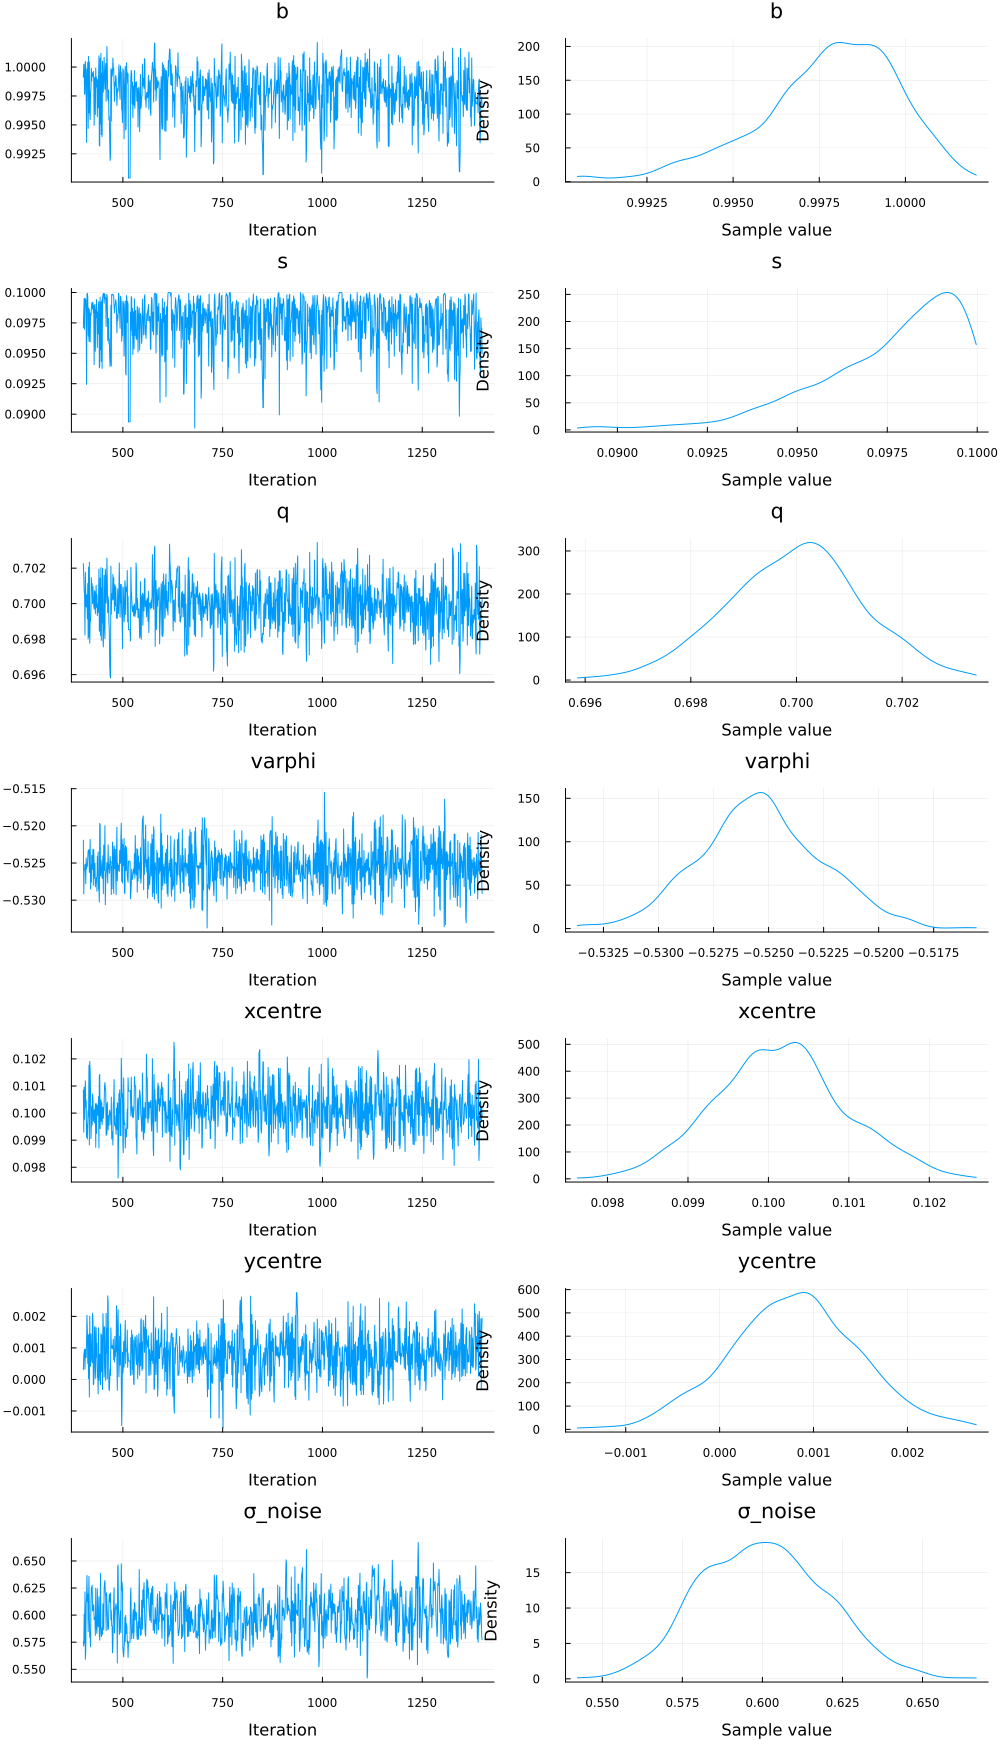

In [9]:
ChainPlot = StatsPlots.plot(chain)

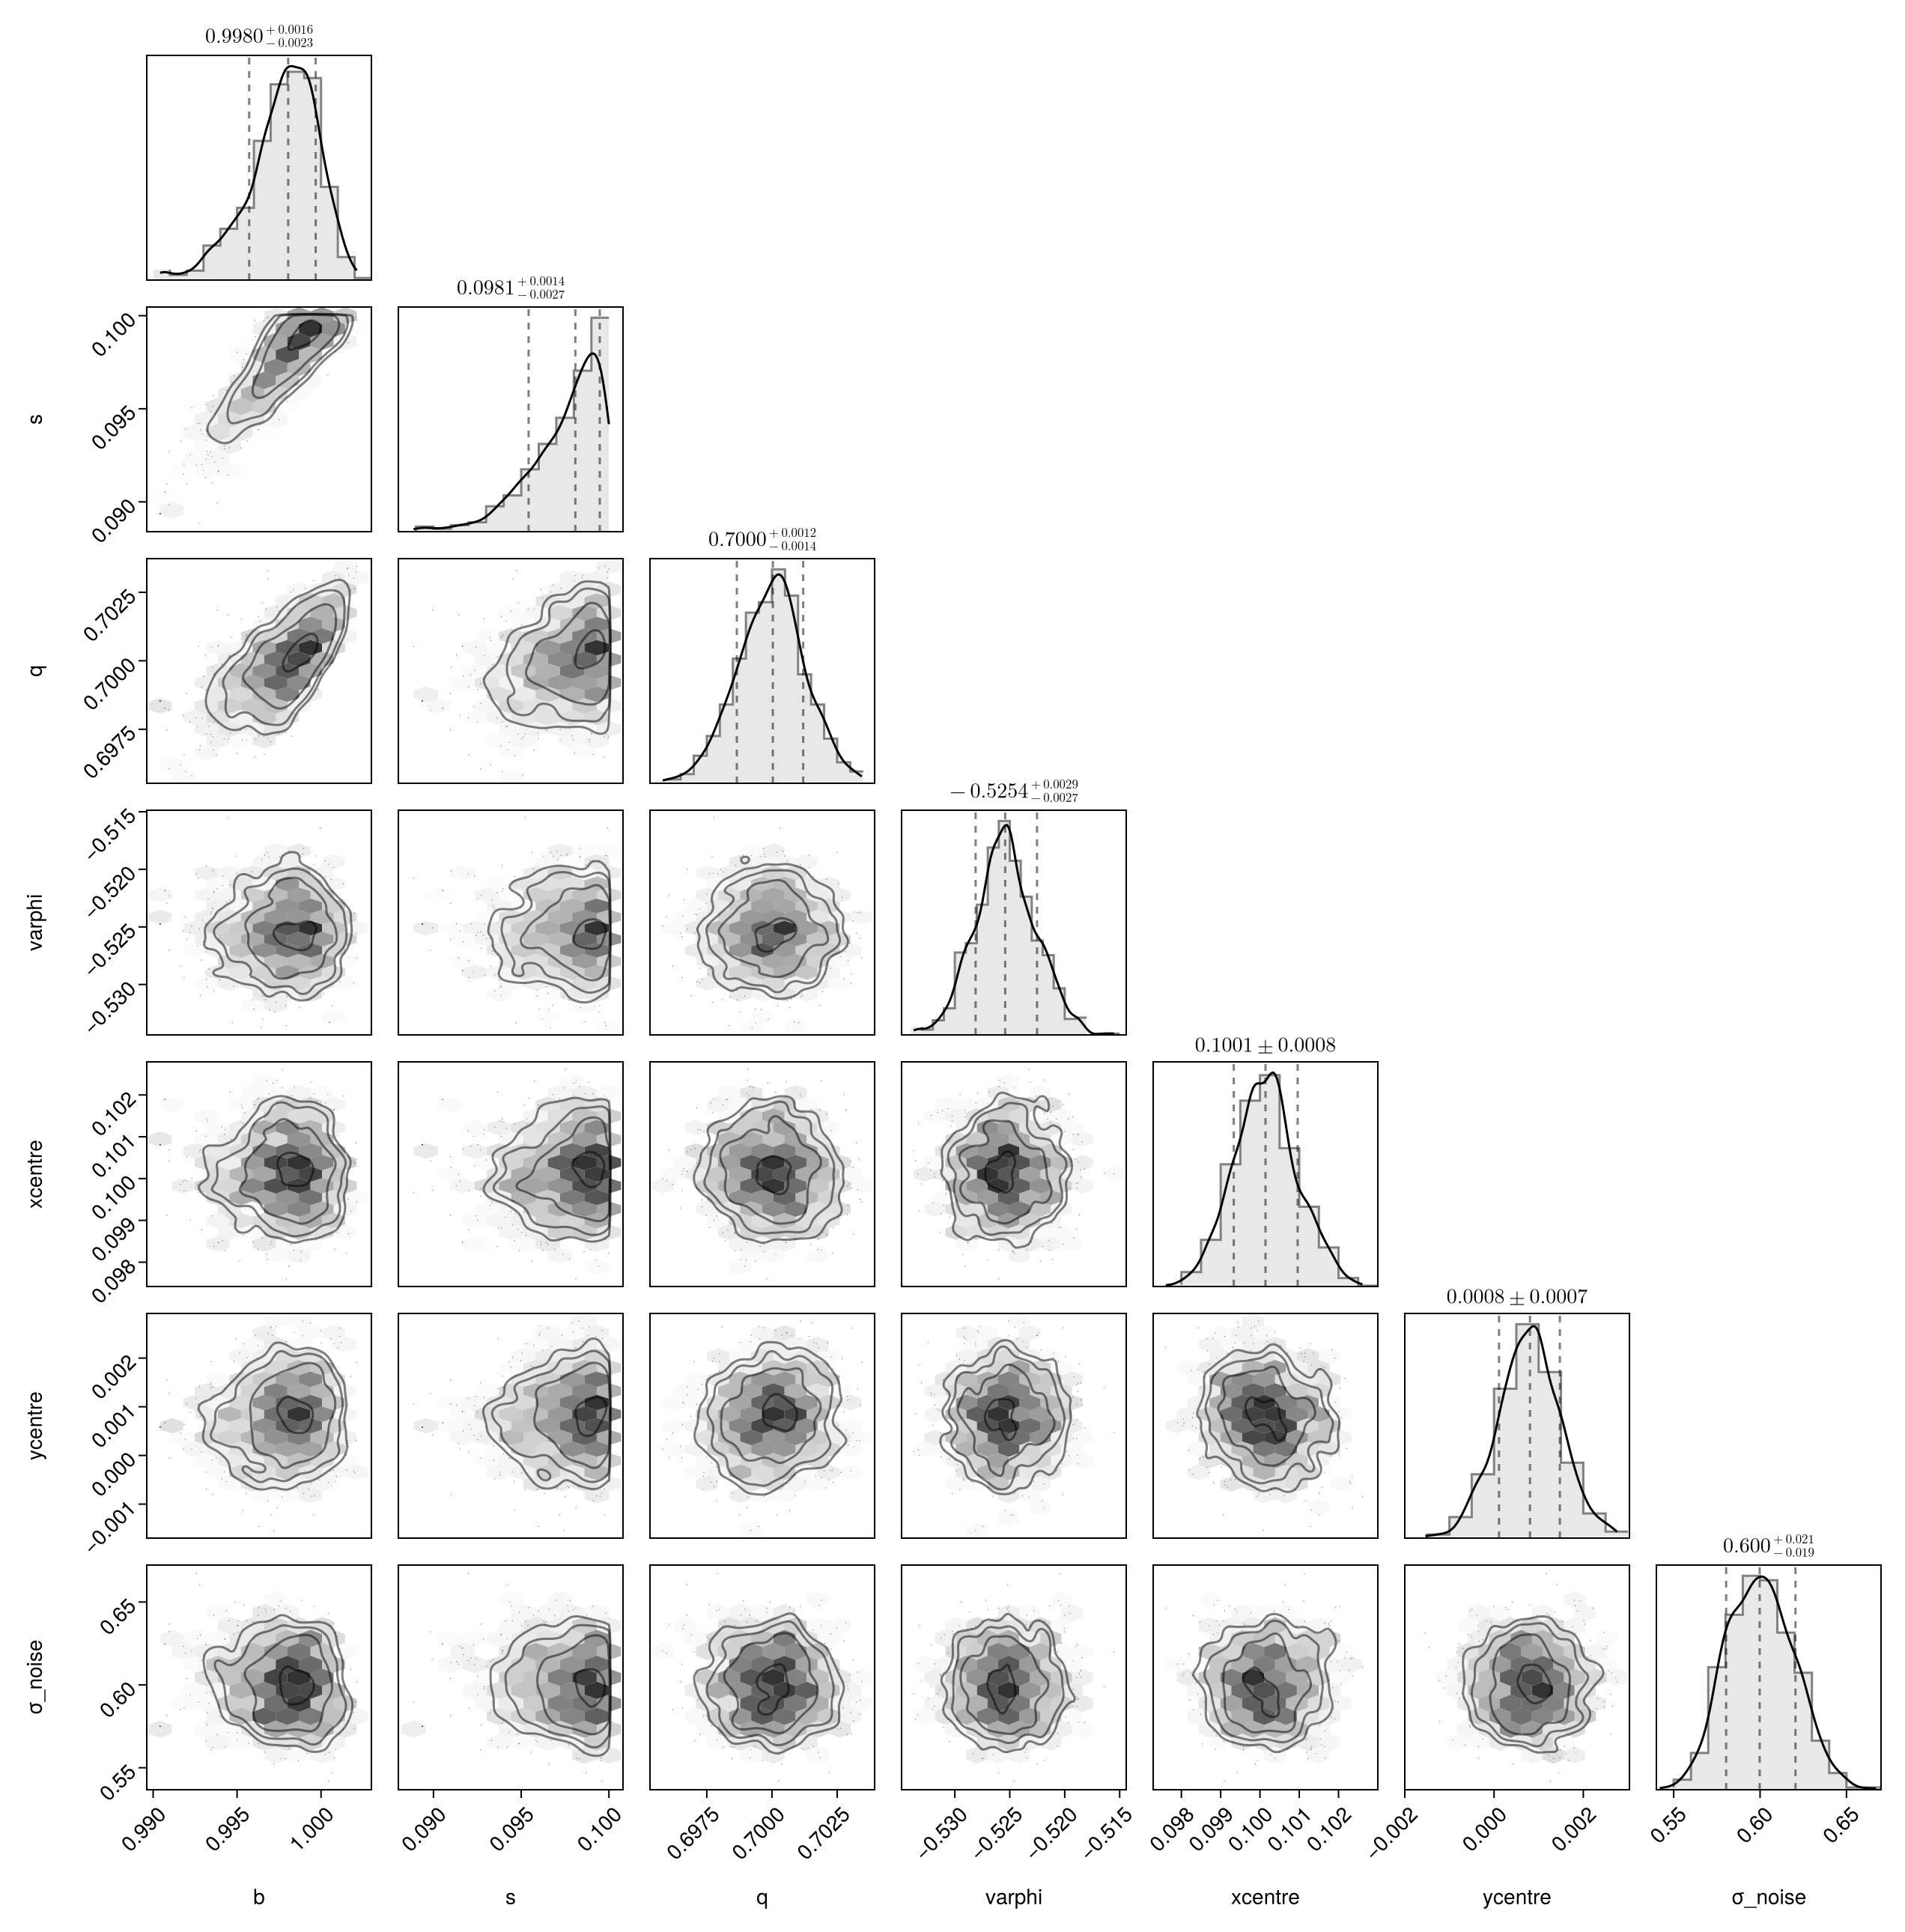

In [10]:
corner_fig = PairPlots.pairplot(chain)

In [11]:
mean_param = Dict([])
para_names = chain.name_map.parameters
for i in range(1,6)
    mean_param[para_names[i]] = mean(chain[:,i,1])
end

LensedLight = LB.LensRayShooting(xg, yg; LensModel=NIEkappa, LensKwargs=mean_param
                            ,SourceProfile=GaussianLight.GaussianSphere,SourceKwargs=LightParaDict);

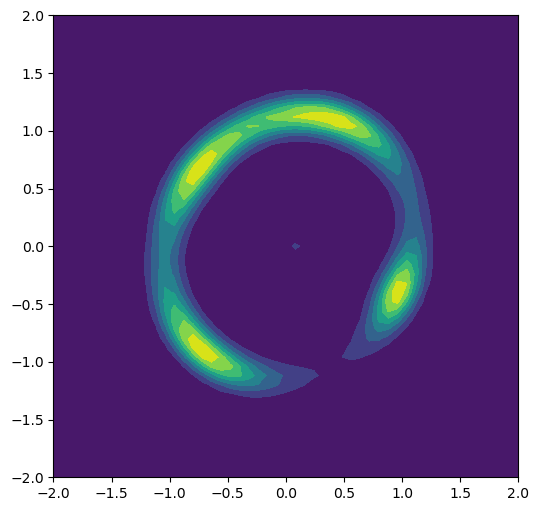

In [12]:
L3 = plt.contourf(xg, yg, LensedLight, size=(450,400), colorbar=true, xlabel="x (arcsec)", ylabel="y (arcsec)")
gcf()

In [13]:
plt.clf()

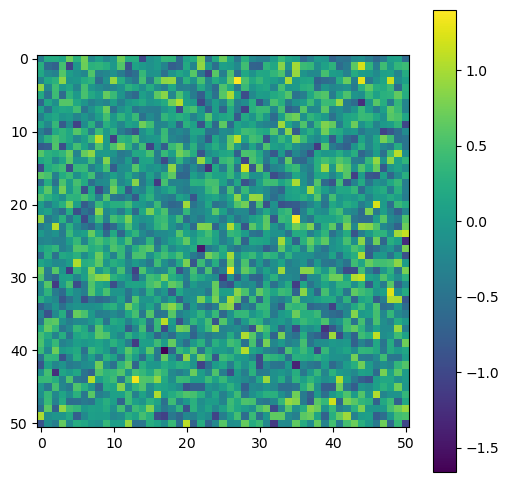

In [15]:
res = LensedLight - data
L4 = plt.imshow(res/mean(data))
plt.colorbar()
gcf()